In [2]:
from src.dataset import DigitAnomalyDataset
from src.encoders import PCAAngleEncoder, AmplitudeEncoder
from src.feature_map import AngleFeatureMap, AmplitudeFeatureMap
from src.kernel import FidelityQuantumKernel, ClassicalRBFKernel
from src.models import OneClassSVMAnomalyModel
from src.anomaly_eval import AnomalyEvaluator
from src.visualizer import AnomalyVisualizer
from src.experiment import QuantumAnomalyExperiment

Experiment: PCA angle quantum kernel
AUC:       0.9429
F1:        0.9167
Precision: 0.9167
Recall:    0.9167

Confusion matrix:
[[ 30  10]
 [ 10 110]]

Classification report:
              precision    recall  f1-score   support

      normal       0.75      0.75      0.75        40
     anomaly       0.92      0.92      0.92       120

    accuracy                           0.88       160
   macro avg       0.83      0.83      0.83       160
weighted avg       0.88      0.88      0.88       160



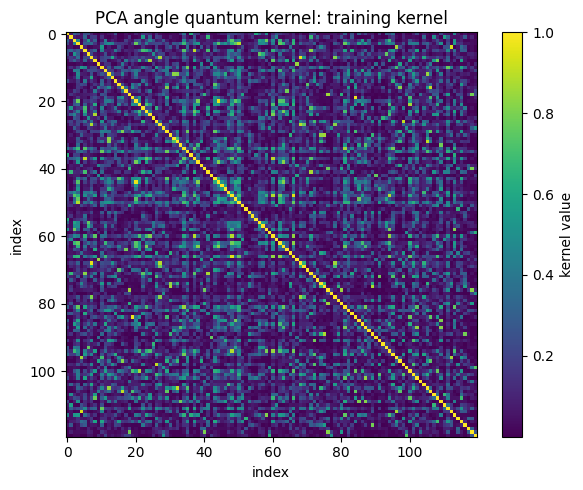

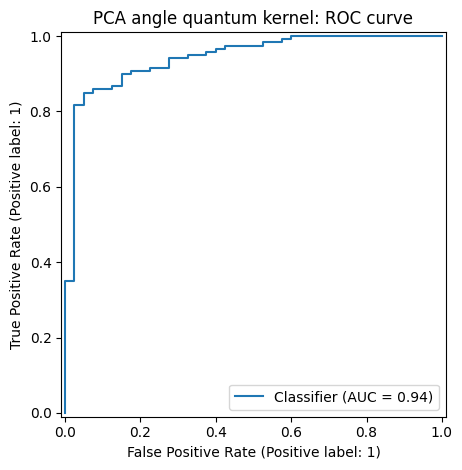

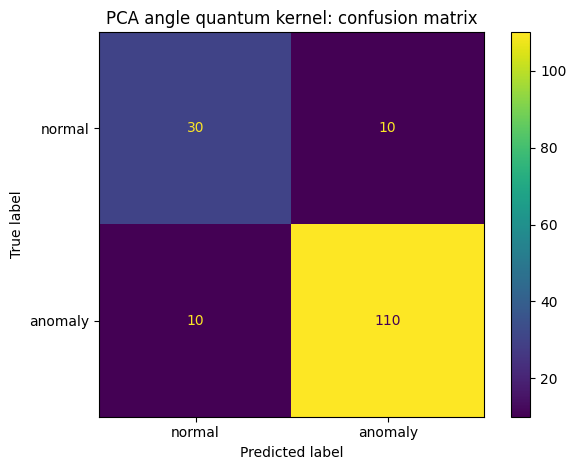

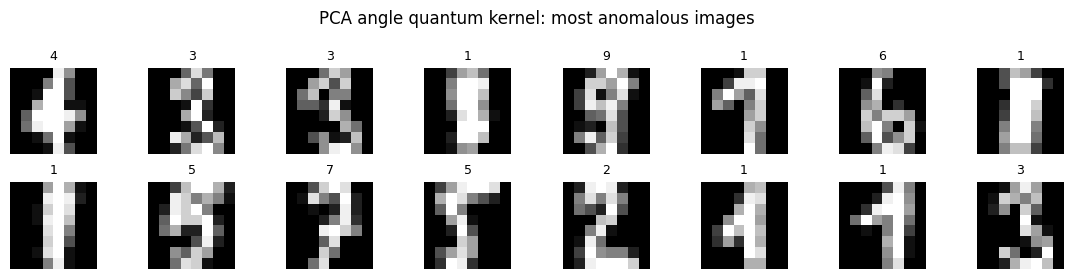

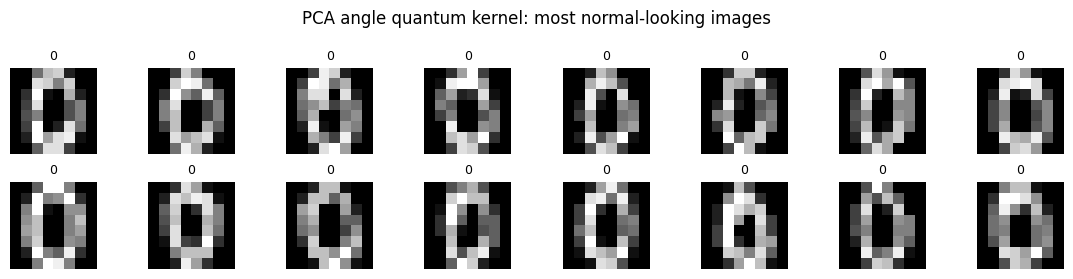

In [20]:
dataset = DigitAnomalyDataset(
    normal_digit=0,
    anomaly_digits=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    n_train_normal=120,
    n_test_normal=40,
    n_test_anomaly=120,
    random_state=7,
)

pca_quantum_experiment = QuantumAnomalyExperiment(
    name="PCA angle quantum kernel",
    dataset=dataset,
    encoder=PCAAngleEncoder(n_components=4),
    kernel=FidelityQuantumKernel(
        feature_map=AngleFeatureMap(reps=2)
    ),
    model=OneClassSVMAnomalyModel(nu=0.1),
    evaluator=AnomalyEvaluator(threshold_strategy="expected_fraction"),
    visualizer=AnomalyVisualizer(),
)

pca_quantum_results = pca_quantum_experiment.run(verbose=False)
pca_quantum_experiment.summarize()
pca_quantum_experiment.plot_results()

Experiment: experiment
AUC:       0.9998
F1:        0.9917
Precision: 0.9917
Recall:    0.9917

Confusion matrix:
[[ 39   1]
 [  1 119]]

Classification report:
              precision    recall  f1-score   support

      normal       0.97      0.97      0.97        40
     anomaly       0.99      0.99      0.99       120

    accuracy                           0.99       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.99      0.99      0.99       160



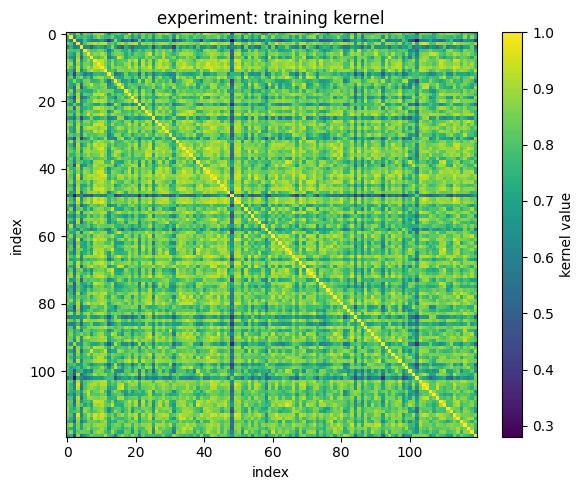

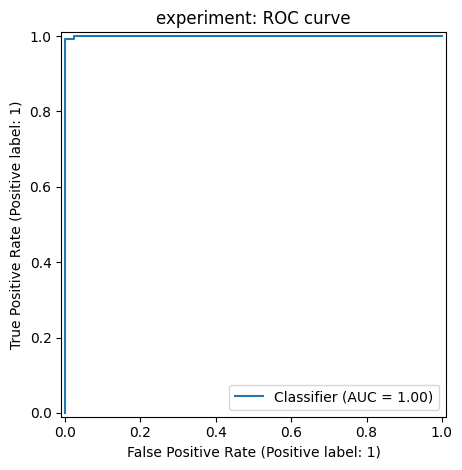

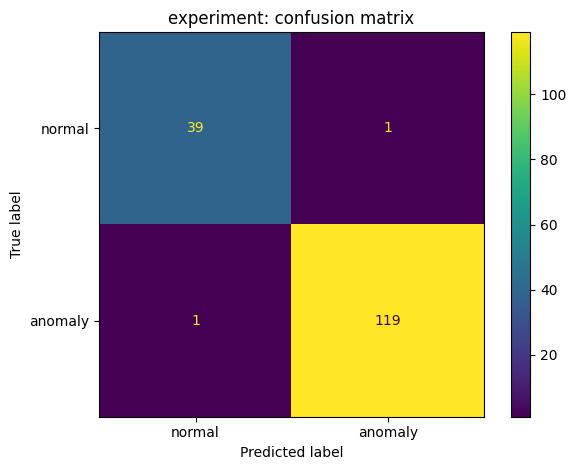

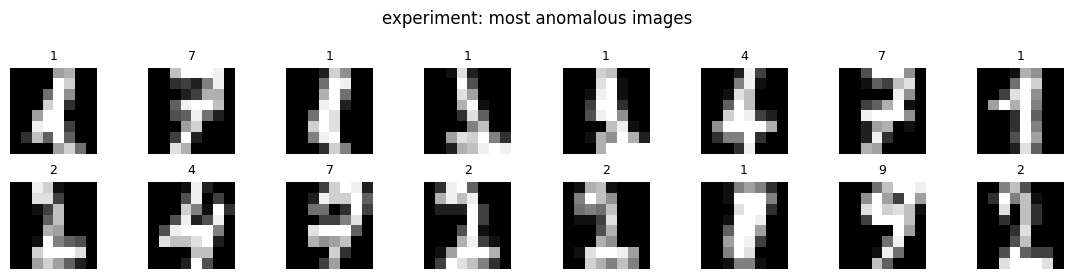

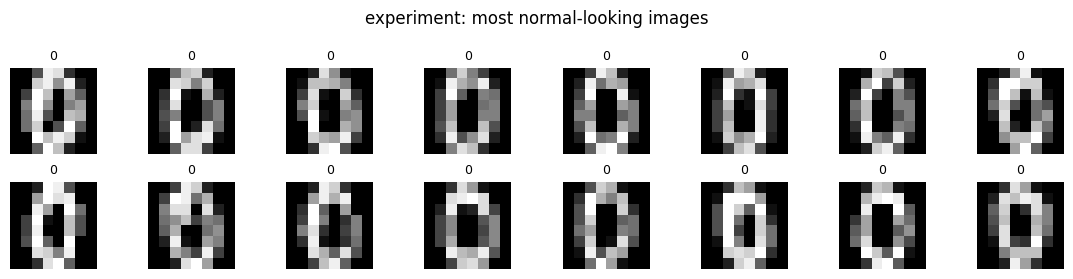

In [17]:
dataset = DigitAnomalyDataset(
    normal_digit=0,
    anomaly_digits=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    n_train_normal=120,
    n_test_normal=40,
    n_test_anomaly=120,
    random_state=9,
)

quantum_experiment = QuantumAnomalyExperiment(
    dataset=dataset,
    encoder=AmplitudeEncoder(),
    kernel=FidelityQuantumKernel(feature_map=AmplitudeFeatureMap()),
    model=OneClassSVMAnomalyModel(nu=0.1),
    evaluator=AnomalyEvaluator(threshold_strategy="expected_fraction"),
    visualizer=AnomalyVisualizer(),
)

quantum_results = quantum_experiment.run(verbose=False)
quantum_experiment.summarize()
quantum_experiment.plot_results()

Mistake indices: [ 11 143]
True anomaly labels y_test: [0 1]
Predicted labels: [1 0]
Original digit labels: [0 9]
Scores: [0.32220975 0.32121765]


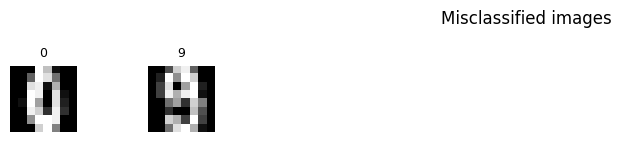

In [19]:
import numpy as np

metrics = quantum_results["metrics"]
y_test = quantum_results["y_test"]
y_pred = metrics["y_pred"]
scores = quantum_results["scores"]
raw = quantum_results["raw"]

mistake_idx = np.where(y_test != y_pred)[0]

print("Mistake indices:", mistake_idx)
print("True anomaly labels y_test:", y_test[mistake_idx])
print("Predicted labels:", y_pred[mistake_idx])
print("Original digit labels:", raw["test_labels_original"][mistake_idx])
print("Scores:", scores[mistake_idx])

viz = AnomalyVisualizer()
viz.plot_images(
    raw["test_images"][mistake_idx],
    labels=raw["test_labels_original"][mistake_idx],
    n=len(mistake_idx),
    title="Misclassified images"
)

Experiment: experiment
AUC:       0.9998
F1:        0.9917
Precision: 0.9917
Recall:    0.9917

Confusion matrix:
[[ 39   1]
 [  1 119]]

Classification report:
              precision    recall  f1-score   support

      normal       0.97      0.97      0.97        40
     anomaly       0.99      0.99      0.99       120

    accuracy                           0.99       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.99      0.99      0.99       160



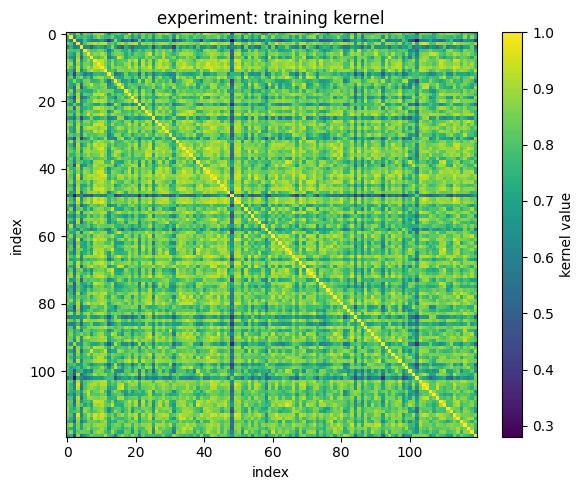

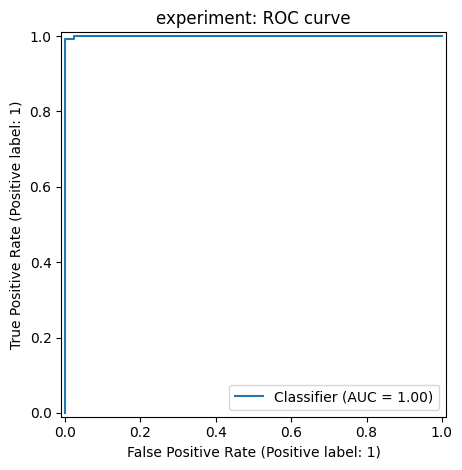

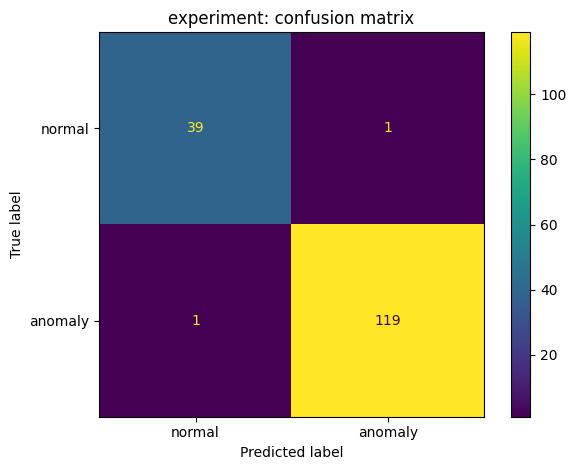

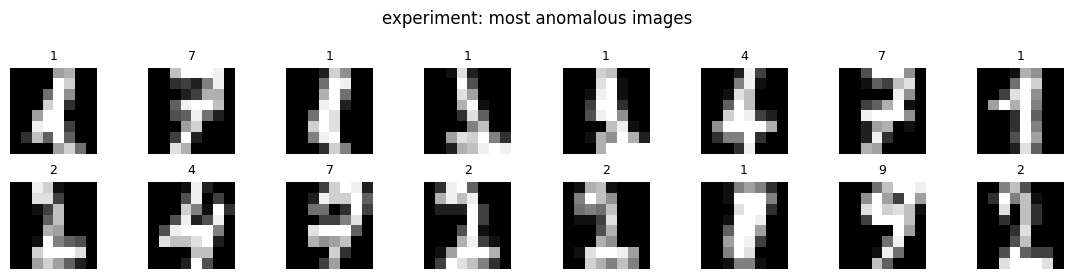

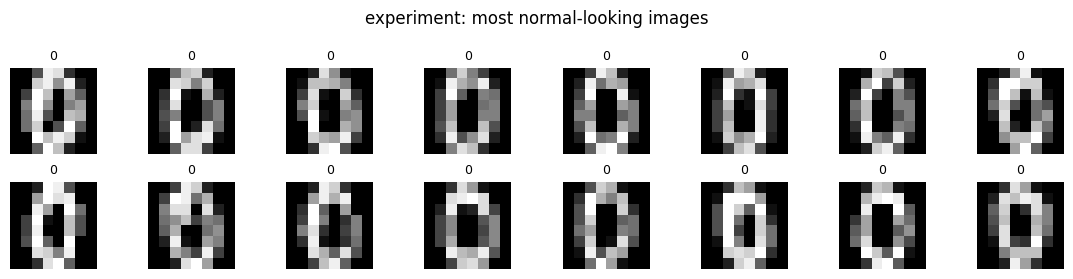

In [21]:
dataset = DigitAnomalyDataset(
    normal_digit=0,
    anomaly_digits=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    n_train_normal=120,
    n_test_normal=40,
    n_test_anomaly=120,
    random_state=9,
)

classical_experiment = QuantumAnomalyExperiment(
    dataset=dataset,
    encoder=AmplitudeEncoder(),
    kernel=ClassicalRBFKernel(gamma=1.0),
    model=OneClassSVMAnomalyModel(nu=0.1),
    evaluator=AnomalyEvaluator(threshold_strategy="expected_fraction"),
    visualizer=AnomalyVisualizer(),
)

quantum_results = quantum_experiment.run(verbose=False)
quantum_experiment.summarize()
quantum_experiment.plot_results()

Experiment: experiment
AUC:       0.9998
F1:        0.9917
Precision: 0.9917
Recall:    0.9917

Confusion matrix:
[[ 39   1]
 [  1 119]]

Classification report:
              precision    recall  f1-score   support

      normal       0.97      0.97      0.97        40
     anomaly       0.99      0.99      0.99       120

    accuracy                           0.99       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.99      0.99      0.99       160



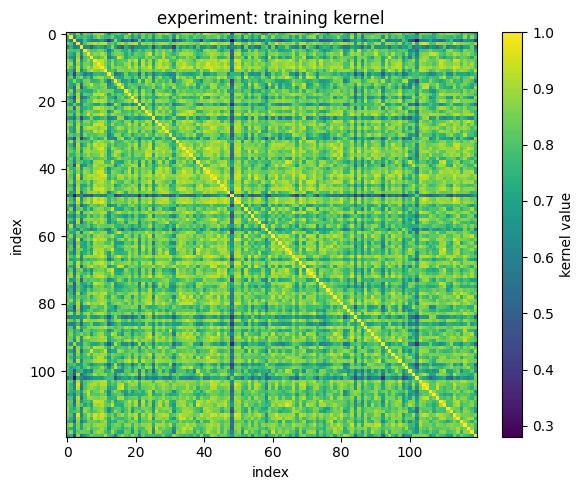

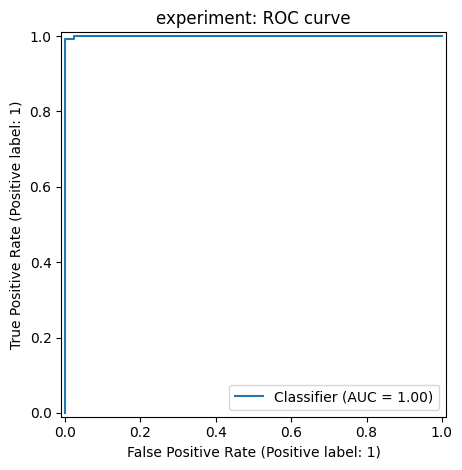

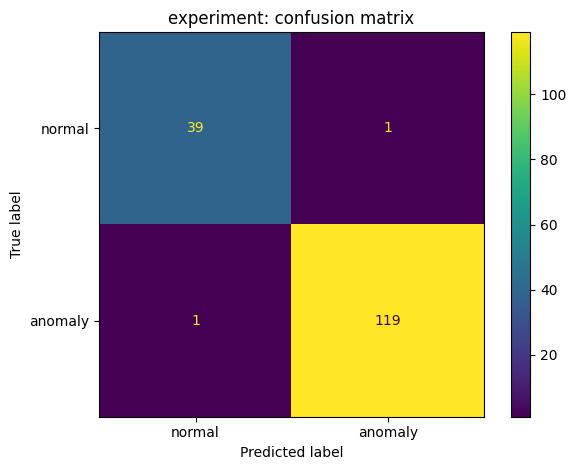

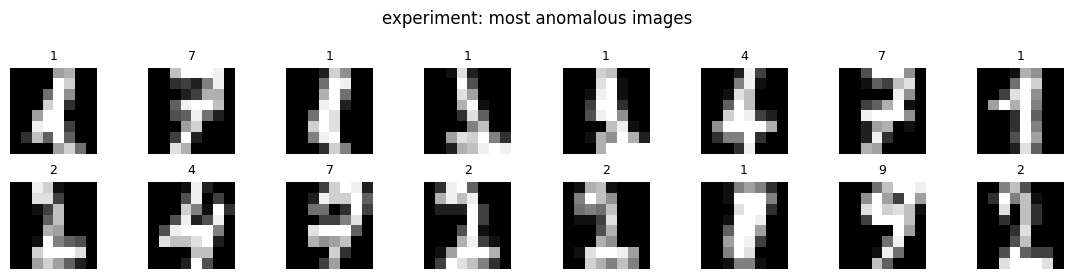

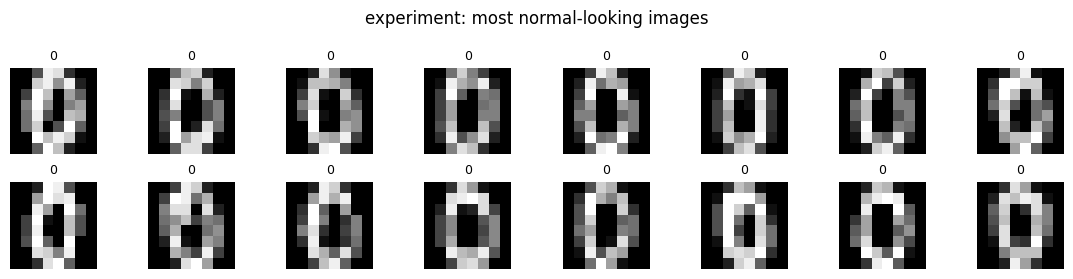

In [22]:
dataset = DigitAnomalyDataset(
    normal_digit=0,
    anomaly_digits=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    n_train_normal=120,
    n_test_normal=40,
    n_test_anomaly=120,
    random_state=9,
)

classical_experiment = QuantumAnomalyExperiment(
    dataset=dataset,
    encoder=PCAAngleEncoder(),
    kernel=ClassicalRBFKernel(gamma=1.0),
    model=OneClassSVMAnomalyModel(nu=0.1),
    evaluator=AnomalyEvaluator(threshold_strategy="expected_fraction"),
    visualizer=AnomalyVisualizer(),
)

quantum_results = quantum_experiment.run(verbose=False)
quantum_experiment.summarize()
quantum_experiment.plot_results()